# Short-difference masking-scale test

A sidecar-only test on ASAS-SN 197569146752. The production masked-GP code is left unchanged; only the internal masking scale is temporarily replaced by $1.4826\,\mathrm{MAD}[(r_{i+1}-r_i)/\sqrt{2}]$, with the median reported error as a floor.

In [1]:
from contextlib import contextmanager
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

candidate_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next(
    (p for p in candidate_roots if (p / 'pyproject.toml').is_file() and (p / 'malca' / 'core' / 'baseline.py').is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError(f'Could not find the MALCA repository above {Path.cwd()}')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import malca.core.baseline as baseline_module
from malca.core.utils import clean_lc
from malca.io.lightcurve_io import load_lightcurve_df, to_asassn_algorithm_frame
from malca.plotting.lightcurve_publication import FIG_SINGLE_COL_WIDTH, PUBLICATION_STYLE, finalize_publication_figure
from malca.stv.events import DEFAULT_BASELINE_KWARGS

TARGET_ID = '197569146752'
JD_OFFSET = 2458000.0
RUN_ROOT = repo_root / 'output' / 'runs' / 'dat3-full-extended_2026-07-01-v4'
LIGHTCURVE_PATH = RUN_ROOT / 'bundle_assets' / 'lightcurves' / f'{TARGET_ID}.dat3'
OUTPUT_DIR = repo_root / 'output' / 'pdf' / 'baseline_methods' / 'diagnostics'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = OUTPUT_DIR / f'short_difference_mask_test_{TARGET_ID}_g.pdf'
PNG_PATH = OUTPUT_DIR / f'short_difference_mask_test_{TARGET_ID}_g.png'


In [2]:
original_mask_sigma = baseline_module._mask_excursion_sigma

def short_difference_sigma(mag, base_rough, finite, mag_err):
    residual = np.asarray(mag, float) - np.asarray(base_rough, float)
    valid = np.asarray(finite, bool) & np.isfinite(residual)
    values = residual[valid]
    if values.size < 3:
        return original_mask_sigma(mag, base_rough, finite, mag_err)
    differences = np.diff(values) / np.sqrt(2.0)
    center = float(np.nanmedian(differences))
    sigma_short = float(baseline_module.MAD_SCALE * np.nanmedian(np.abs(differences - center)))
    errors = np.asarray(mag_err, float)
    error_values = errors[np.asarray(finite, bool) & np.isfinite(errors) & (errors > 0)]
    error_floor = float(np.nanmedian(error_values)) if error_values.size else 0.0
    return max(sigma_short, error_floor, 1e-6)

@contextmanager
def use_short_difference_mask_scale():
    baseline_module._mask_excursion_sigma = short_difference_sigma
    try:
        yield
    finally:
        baseline_module._mask_excursion_sigma = original_mask_sigma

canonical = load_lightcurve_df(LIGHTCURVE_PATH, apply_quality=True)
cleaned = clean_lc(to_asassn_algorithm_frame(canonical)).reset_index(drop=True)
bands = pd.to_numeric(cleaned['v_g_band'], errors='coerce')
lightcurve = cleaned.loc[np.isclose(bands, 0.0)].copy().reset_index(drop=True)
if lightcurve.empty:
    raise ValueError(f'No g-band data found for {TARGET_ID}.')

current = baseline_module.per_camera_gp_baseline_masked(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True)
with use_short_difference_mask_scale():
    short_difference = baseline_module.per_camera_gp_baseline_masked(lightcurve, **DEFAULT_BASELINE_KWARGS).reset_index(drop=True)

rows = []
for camera in sorted(lightcurve['camera#'].dropna().unique(), key=str):
    current_camera = current.loc[current['camera#'] == camera]
    short_camera = short_difference.loc[short_difference['camera#'] == camera]
    rough_residual = current_camera['mag'].to_numpy(float) - current_camera['base_rough'].to_numpy(float)
    differences = np.diff(rough_residual) / np.sqrt(2.0)
    difference_center = float(np.nanmedian(differences))
    sigma_short = float(baseline_module.MAD_SCALE * np.nanmedian(np.abs(differences - difference_center)))
    rows.append({
        'camera': camera,
        'points': int(len(current_camera)),
        'sigma_short_mag': sigma_short,
        'current_masked': int(current_camera['is_masked'].sum()),
        'short_difference_masked': int(short_camera['is_masked'].sum()),
        'short_difference_fraction': float(short_camera['is_masked'].mean()),
        'short_difference_source': ','.join(sorted(short_camera['baseline_source'].astype(str).unique())),
        'short_difference_consensus': bool(short_camera['needs_consensus'].any()),
    })
comparison = pd.DataFrame(rows).set_index('camera')
display(comparison)
print('Current masked:', int(current['is_masked'].sum()), '/', len(current))
print('Short-difference masked:', int(short_difference['is_masked'].sum()), '/', len(short_difference))


,points,sigma_short_mag,current_masked,short_difference_masked,short_difference_fraction,short_difference_source,short_difference_consensus
camera,,,,,,,
3,198,0.018816,0,191,0.964646,camera_median_fallback,False
4,355,0.015826,114,342,0.963380,masked_gp,False
5,235,0.019510,22,231,0.982979,camera_median_fallback,False
6,212,0.016629,0,212,1.000000,camera_median_fallback,True
7,256,0.016843,0,225,0.878906,masked_gp,True


Current masked: 136 / 1256
Short-difference masked: 1201 / 1256


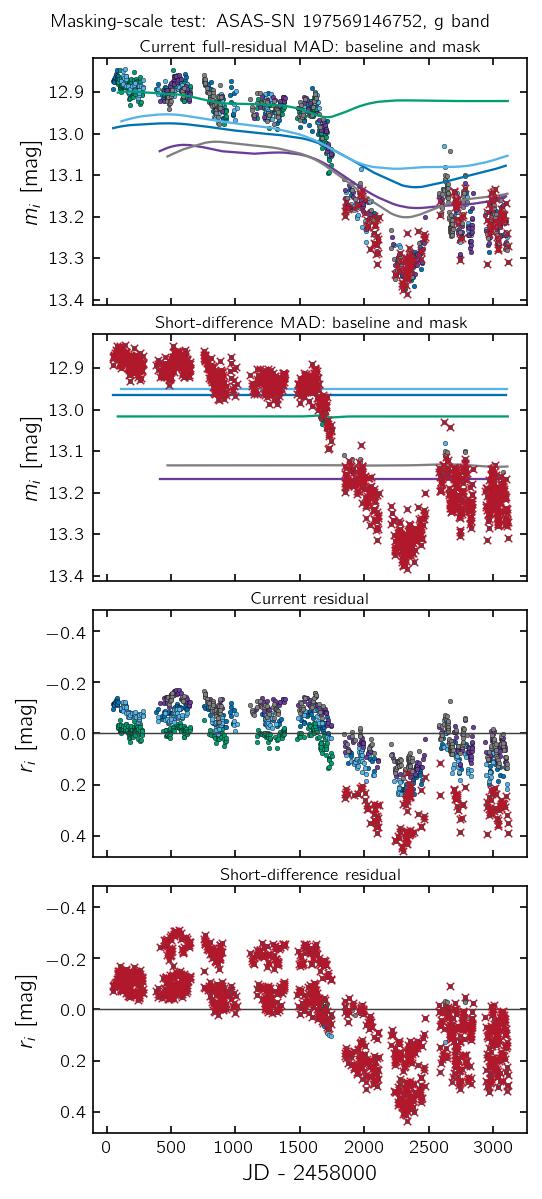

/Users/calder/code/malca/output/pdf/baseline_methods/diagnostics/short_difference_mask_test_197569146752_g.pdf
/Users/calder/code/malca/output/pdf/baseline_methods/diagnostics/short_difference_mask_test_197569146752_g.png


In [3]:
CAMERA_PALETTE = ('#0072B2', '#009E73', '#56B4E9', '#6A3D9A', '#7F7F7F', '#E69F00')
camera_order = sorted(lightcurve['camera#'].dropna().unique(), key=str)
camera_colors = {camera: CAMERA_PALETTE[i % len(CAMERA_PALETTE)] for i, camera in enumerate(camera_order)}

def plot_baseline_panel(ax, frame, title):
    for camera, sub in frame.groupby('camera#', sort=True):
        sub = sub.sort_values('JD')
        x = sub['JD'].to_numpy(float) - JD_OFFSET
        color = camera_colors[camera]
        ax.scatter(x, sub['mag'], s=5, color=color, edgecolors='black', linewidths=0.18, zorder=2)
        ax.plot(x, sub['baseline'], color=color, linewidth=1.1, zorder=3)
        masked = sub['is_masked'].fillna(False).to_numpy(bool)
        if masked.any():
            ax.scatter(x[masked], sub.loc[masked, 'mag'], s=13, marker='x', color='#b2182b', linewidths=0.7, zorder=5)
    ax.invert_yaxis()
    ax.set_ylabel(r'$m_i$ [mag]')
    ax.set_title(title, fontsize=8, pad=3)

def plot_residual_panel(ax, frame, title):
    for camera, sub in frame.groupby('camera#', sort=True):
        sub = sub.sort_values('JD')
        x = sub['JD'].to_numpy(float) - JD_OFFSET
        color = camera_colors[camera]
        ax.scatter(x, sub['resid'], s=5, color=color, edgecolors='black', linewidths=0.18, zorder=2)
        masked = sub['is_masked'].fillna(False).to_numpy(bool)
        if masked.any():
            ax.scatter(x[masked], sub.loc[masked, 'resid'], s=13, marker='x', color='#b2182b', linewidths=0.7, zorder=5)
    ax.axhline(0, color='0.25', linewidth=0.7)
    ax.invert_yaxis()
    ax.set_ylabel(r'$r_i$ [mag]')
    ax.set_title(title, fontsize=8, pad=3)

with plt.rc_context(PUBLICATION_STYLE):
    fig, axes = plt.subplots(4, 1, figsize=(FIG_SINGLE_COL_WIDTH, 8.0), sharex=True)
    plot_baseline_panel(axes[0], current, 'Current full-residual MAD: baseline and mask')
    plot_baseline_panel(axes[1], short_difference, 'Short-difference MAD: baseline and mask')
    plot_residual_panel(axes[2], current, 'Current residual')
    plot_residual_panel(axes[3], short_difference, 'Short-difference residual')
    magnitude_limits = axes[0].get_ylim()
    axes[1].set_ylim(magnitude_limits)
    residual_values = np.concatenate([current['resid'].to_numpy(float), short_difference['resid'].to_numpy(float)])
    residual_limit = max(0.15, float(np.nanmax(np.abs(residual_values))) * 1.05)
    axes[2].set_ylim(residual_limit, -residual_limit)
    axes[3].set_ylim(residual_limit, -residual_limit)
    axes[-1].set_xlabel('JD - 2458000')
    for ax in axes:
        ax.tick_params(direction='in', top=True, right=True)
    fig.suptitle(f'Masking-scale test: ASAS-SN {TARGET_ID}, g band', fontsize=9)
    finalize_publication_figure(fig, rect=(0, 0, 1, 0.982))
    fig.savefig(PDF_PATH)
    fig.savefig(PNG_PATH, dpi=300)
    plt.show()

print(PDF_PATH)
print(PNG_PATH)
